In [1]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

In [2]:
# ── 資料載入 ──

def get_subject_id(filename):
    return filename.split('_ses-')[0]

def scan_session_folder(folder_path):
    result = {}
    for fname in sorted(os.listdir(folder_path)):
        if fname.endswith('.mat'):
            result[get_subject_id(fname)] = os.path.join(folder_path, fname)
    return result

def load_band_energy(filepath):
    with h5py.File(filepath, 'r') as f:
        data = np.array(f['band_energy']).T
    return data

def load_group(ss01_map, ss02_map, ss03_map, complete_subs):
    X1, X2, X3 = [], [], []
    for sub_id in complete_subs:
        X1.append(load_band_energy(ss01_map[sub_id]))
        X2.append(load_band_energy(ss02_map[sub_id]))
        X3.append(load_band_energy(ss03_map[sub_id]))
    return np.array(X1), np.array(X2), np.array(X3)

BASE_MASTER  = r'D:\Tseng\圍棋\master\band_energy_batch_outputs_2026'
BASE_PROF    = r'D:\Tseng\圍棋\prof\band_energy_batch_outputs_2026'

PATHS = {
    'master':  {s: os.path.join(BASE_MASTER,  s) for s in ['ss01','ss02','ss03']},
    'prof':    {s: os.path.join(BASE_PROF,    s) for s in ['ss01','ss02','ss03']},
}

maps = {}
complete = {}
for group in ['master', 'prof']:
    m1 = scan_session_folder(PATHS[group]['ss01'])
    m2 = scan_session_folder(PATHS[group]['ss02'])
    m3 = scan_session_folder(PATHS[group]['ss03'])
    maps[group] = (m1, m2, m3)
    complete[group] = sorted(set(m1) & set(m2) & set(m3))
    print(f"[{group}] 完整 subject：{len(complete[group])} 人")

print("\n載入資料...")
X_m1, X_m2, X_m3 = load_group(*maps['master'],  complete['master'])
X_p1, X_p2, X_p3 = load_group(*maps['prof'],    complete['prof'])
print("完成")

[master] 完整 subject：20 人
[prof] 完整 subject：8 人

載入資料...
完成


In [3]:
# ── 特徵提取 & 準備 LOSO 資料集 ──

CLASS_NAMES = ['master', 'prof']

def extract_features(X):
    """(n, 32ch, 39time, 5bands) → (n, 160)"""
    X = np.log(X + 1e-8)
    X = X[:, :, 1:-1, :]
    X = X.mean(axis=2)
    return X.reshape(len(X), -1)

n_m = len(complete['master'])
n_p = len(complete['prof'])
n_total = n_m + n_p

# 特徵提取
Fm1, Fm2, Fm3 = extract_features(X_m1), extract_features(X_m2), extract_features(X_m3)
Fp1, Fp2, Fp3 = extract_features(X_p1), extract_features(X_p2), extract_features(X_p3)

X_m_all = np.vstack([Fm1, Fm2, Fm3])
X_p_all = np.vstack([Fp1, Fp2, Fp3])
X_all = np.vstack([X_m_all, X_p_all])

# 標籤：0=master, 1=prof
y_all = np.concatenate([np.zeros(n_m * 3), np.ones(n_p * 3)])

# Subject ID
subject_ids = complete['master'] + complete['prof']
subject_split = np.concatenate([
    np.repeat(complete['master'], 3),
    np.repeat(complete['prof'], 3),
])

print(f"X_all shape: {X_all.shape}")
print(f"Total subjects: {n_total}")
print(f"  Master: {n_m}, Prof: {n_p}")
print(f"y 分佈: {np.bincount(y_all.astype(int)).tolist()}")
print(f"\nLOSO 將執行 {n_total} 次迴圈")

X_all shape: (84, 160)
Total subjects: 28
  Master: 20, Prof: 8
y 分佈: [60, 24]

LOSO 將執行 28 次迴圈


In [4]:
# ── LOSO 訓練 (160 dims) ──

def make_pipeline():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=40)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       class_weight='balanced', random_state=42)),
    ])

results_160   = []
all_preds_160 = []
all_true_160  = []

for test_subject in subject_ids:
    test_mask  = subject_split == test_subject
    train_mask = ~test_mask

    X_tr, y_tr = X_all[train_mask], y_all[train_mask].astype(int)
    X_te, y_te = X_all[test_mask],  y_all[test_mask].astype(int)

    pipe = make_pipeline()
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)

    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='macro', zero_division=0)

    results_160.append({'acc': acc, 'f1': f1, 'subject': test_subject})
    all_preds_160.extend(preds)
    all_true_160.extend(y_te)

mean_acc_160 = np.mean([r['acc'] for r in results_160])
mean_f1_160  = np.mean([r['f1']  for r in results_160])
all_preds_160 = np.array(all_preds_160)
all_true_160 = np.array(all_true_160)

print(f">>> 160 dims LOSO 平均  Acc={mean_acc_160:.3f}  F1={mean_f1_160:.3f}")
print(f"\nPer-subject 結果 (前 10):")
for i, r in enumerate(results_160[:10]):
    print(f"  {r['subject']:<10s}: Acc={r['acc']:.3f}  F1={r['f1']:.3f}")

>>> 160 dims LOSO 平均  Acc=0.881  F1=0.818

Per-subject 結果 (前 10):
  sub-52    : Acc=1.000  F1=1.000
  sub-55    : Acc=1.000  F1=1.000
  sub-56    : Acc=1.000  F1=1.000
  sub-57    : Acc=0.333  F1=0.250
  sub-58    : Acc=1.000  F1=1.000
  sub-59    : Acc=1.000  F1=1.000
  sub-60    : Acc=1.000  F1=1.000
  sub-61    : Acc=1.000  F1=1.000
  sub-63    : Acc=1.000  F1=1.000
  sub-67    : Acc=1.000  F1=1.000


整體混淆矩陣 (160 dims):
[[55  5]
 [ 5 19]]

Classification Report (160 dims):
              precision    recall  f1-score   support

      master       0.92      0.92      0.92        60
        prof       0.79      0.79      0.79        24

    accuracy                           0.88        84
   macro avg       0.85      0.85      0.85        84
weighted avg       0.88      0.88      0.88        84



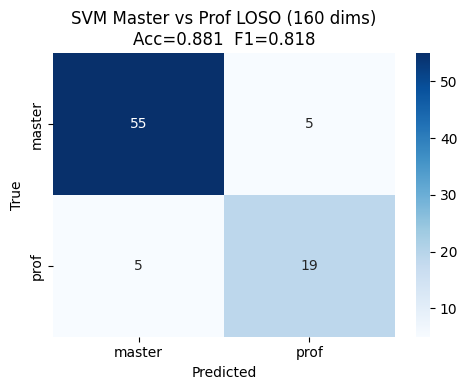

In [5]:
# ── 160 dims 混淆矩陣 & 詳細報告 ──

cm = confusion_matrix(all_true_160, all_preds_160, labels=[0, 1])
print(f"整體混淆矩陣 (160 dims):")
print(cm)
print(f"\nClassification Report (160 dims):")
print(classification_report(all_true_160, all_preds_160, target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'SVM Master vs Prof LOSO (160 dims)\nAcc={mean_acc_160:.3f}  F1={mean_f1_160:.3f}')
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM\svm_master_prof_loso_160_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# ── top10ch_all_bands 特徵提取 ──

BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
TOP_CHS = [0, 6, 7, 10, 13, 14, 21, 22, 28, 31]

def extract_selected(X_raw, channels, bands):
    X = np.log(X_raw + 1e-8)
    X = X[:, :, 1:-1, :]
    X = X.mean(axis=2)
    X = X[:, channels, :]
    X = X[:, :, bands]
    return X.reshape(len(X), -1)

raw_m = [X_m1, X_m2, X_m3]
raw_p = [X_p1, X_p2, X_p3]

ch_sel = [0, 6, 7, 10, 13, 14, 21, 22, 28, 31]
bands_sel = [0, 1, 2, 3, 4]
pca_n = 20

F_m_sel = [extract_selected(Xr, ch_sel, bands_sel) for Xr in raw_m]
F_p_sel = [extract_selected(Xr, ch_sel, bands_sel) for Xr in raw_p]

X_m_sel = np.vstack(F_m_sel)
X_p_sel = np.vstack(F_p_sel)
X_sel = np.vstack([X_m_sel, X_p_sel])

print(f"top10ch_all_bands 特徵維度: {X_sel.shape[1]}")

top10ch_all_bands 特徵維度: 50


In [7]:
# ── LOSO 訓練 (top10ch_all_bands) ──

results_top   = []
all_preds_top = []
all_true_top  = []

for test_subject in subject_ids:
    test_mask  = subject_split == test_subject
    train_mask = ~test_mask

    X_tr, y_tr = X_sel[train_mask], y_all[train_mask].astype(int)
    X_te, y_te = X_sel[test_mask],  y_all[test_mask].astype(int)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=pca_n)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       class_weight='balanced', random_state=42)),
    ])
    pipe.fit(X_tr, y_tr)
    preds = pipe.predict(X_te)

    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='macro', zero_division=0)

    results_top.append({'acc': acc, 'f1': f1, 'subject': test_subject})
    all_preds_top.extend(preds)
    all_true_top.extend(y_te)

mean_acc_top = np.mean([r['acc'] for r in results_top])
mean_f1_top  = np.mean([r['f1']  for r in results_top])
all_preds_top = np.array(all_preds_top)
all_true_top = np.array(all_true_top)

print(f">>> top10ch_all_bands LOSO 平均  Acc={mean_acc_top:.3f}  F1={mean_f1_top:.3f}")
print(f"\nPer-subject 結果 (前 10):")
for i, r in enumerate(results_top[:10]):
    print(f"  {r['subject']:<10s}: Acc={r['acc']:.3f}  F1={r['f1']:.3f}")

>>> top10ch_all_bands LOSO 平均  Acc=0.845  F1=0.770

Per-subject 結果 (前 10):
  sub-52    : Acc=1.000  F1=1.000
  sub-55    : Acc=1.000  F1=1.000
  sub-56    : Acc=0.667  F1=0.400
  sub-57    : Acc=0.333  F1=0.250
  sub-58    : Acc=1.000  F1=1.000
  sub-59    : Acc=0.667  F1=0.400
  sub-60    : Acc=1.000  F1=1.000
  sub-61    : Acc=1.000  F1=1.000
  sub-63    : Acc=1.000  F1=1.000
  sub-67    : Acc=1.000  F1=1.000


整體混淆矩陣 (top10ch_all_bands):
[[53  7]
 [ 6 18]]

Classification Report (top10ch_all_bands):
              precision    recall  f1-score   support

      master       0.90      0.88      0.89        60
        prof       0.72      0.75      0.73        24

    accuracy                           0.85        84
   macro avg       0.81      0.82      0.81        84
weighted avg       0.85      0.85      0.85        84



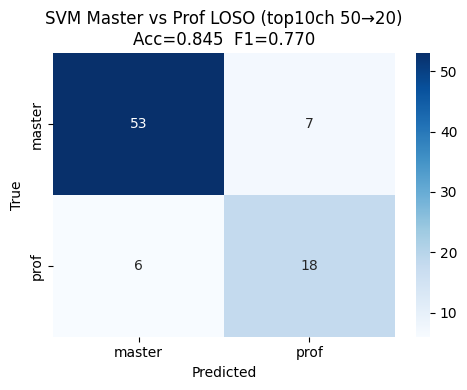

In [8]:
# ── top10ch_all_bands 混淆矩陣 & 詳細報告 ──

cm = confusion_matrix(all_true_top, all_preds_top, labels=[0, 1])
print(f"整體混淆矩陣 (top10ch_all_bands):")
print(cm)
print(f"\nClassification Report (top10ch_all_bands):")
print(classification_report(all_true_top, all_preds_top, target_names=CLASS_NAMES, zero_division=0))

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'SVM Master vs Prof LOSO (top10ch 50→20)\nAcc={mean_acc_top:.3f}  F1={mean_f1_top:.3f}')
plt.tight_layout()
plt.savefig(r'D:\Tseng\game_eeg\SVM\svm_master_prof_loso_top10ch_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── LOSO 結果比較 ──

print("\n" + "="*60)
print("Master vs Prof LOSO 特徵配置比較")
print("="*60)
print(f"{'配置':<30s} {'Dims':>6s}  {'Acc':>6s}  {'F1':>6s}")
print("-"*60)
print(f"{'160 dims (all channels)':<30s} {160:6d}  {mean_acc_160:6.3f}  {mean_f1_160:6.3f}")
print(f"{'top10ch_all_bands (→20)':<30s} {50:6d}  {mean_acc_top:6.3f}  {mean_f1_top:6.3f}")
print("="*60)

# Per-subject 統計
print("\n" + "="*60)
print("Per-Subject 準確度分佈")
print("="*60)
accs_160 = [r['acc'] for r in results_160]
accs_top = [r['acc'] for r in results_top]
print(f"160 dims: min={np.min(accs_160):.3f}, max={np.max(accs_160):.3f}, std={np.std(accs_160):.3f}")
print(f"top10ch:  min={np.min(accs_top):.3f}, max={np.max(accs_top):.3f}, std={np.std(accs_top):.3f}")
print("="*60)


Master vs Prof LOSO 特徵配置比較
配置                               Dims     Acc      F1
------------------------------------------------------------
160 dims (all channels)           160   0.881   0.818
top10ch_all_bands (→20)            50   0.845   0.770

Per-Subject 準確度分佈
160 dims: min=0.333, max=1.000, std=0.203
top10ch:  min=0.333, max=1.000, std=0.227
